In [5]:
#task 3

import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

print ("loading MNIST data ")
train_df = pd.read_csv('mnist_train.csv')
test_df = pd.read_csv('mnist_test.csv')

y_train = train_df.iloc[:,0].values
X_train = train_df.iloc[:,1:].values

y_test = test_df.iloc[:,0].values
X_test = test_df.iloc[:,1:].values

X_train_scaled = X_train / 255.0
X_test_scaled = X_test / 255.0

X_train_tensor = torch.tensor(X_train_scaled,dtype=torch.float32)
y_train_tensor = torch.tensor(y_train,dtype=torch.long)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

batch_size = 64
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
train_dataset = TensorDataset(X_test_tensor,y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size= batch_size ,shuffle= False)


loading MNIST data 



 Starting Training    

Epoch      | Train Loss   | Train Acc    | Test Loss    | Test Acc    
-----------------------------------------------------------------
Epoch 1    | 0.3110       | 90.63     % | 0.1349       | 95.96     %
Epoch 2    | 0.1076       | 96.72     % | 0.0893       | 97.25     %
Epoch 3    | 0.0732       | 97.74     % | 0.0740       | 97.58     %
Epoch 4    | 0.0522       | 98.34     % | 0.0781       | 97.58     %
Epoch 5    | 0.0416       | 98.65     % | 0.0749       | 97.71     %
Epoch 6    | 0.0333       | 98.93     % | 0.0773       | 97.91     %
Epoch 7    | 0.0289       | 99.05     % | 0.0706       | 97.99     %
Epoch 8    | 0.0231       | 99.23     % | 0.0777       | 97.92     %
Epoch 9    | 0.0201       | 99.33     % | 0.0918       | 97.65     %
Epoch 10   | 0.0186       | 99.39     % | 0.0789       | 98.06     %

Training complete!


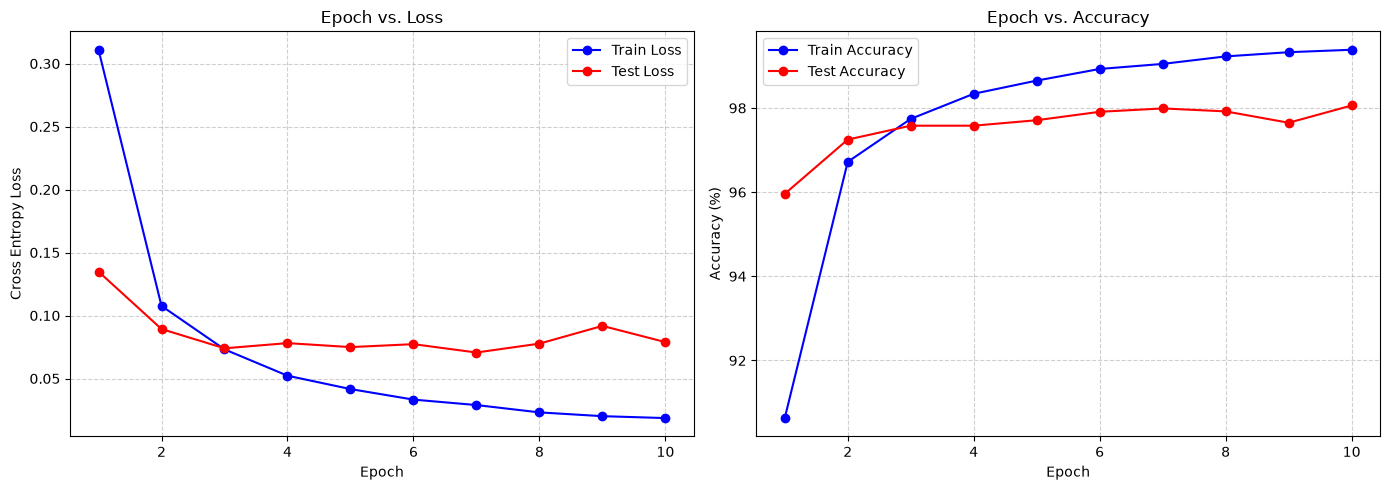

In [15]:
model = nn.Sequential(
    nn.Linear(784,256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128,64),
    nn.ReLU(),
    nn.Linear(64,10)
)
criterion=nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)
epochs=10
print("\n Starting Training    \n")
print(f"{'Epoch':<10} | {'Train Loss':<12} | {'Train Acc':<12} | {'Test Loss':<12} | {'Test Acc':<12}")
print("-" * 65)

train_losses, train_accuracies = [], []
test_losses, test_accuracies = [], []
for epoch in range(epochs):
    model.train() 
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * X_batch.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += y_batch.size(0)
        correct_train += (predicted == y_batch).sum().item()
        
    avg_train_loss = running_train_loss / total_train
    train_acc = (correct_train / total_train) * 100
    model.eval() 
    running_test_loss = 0.0
    correct_test = 0
    total_test = 0
    with torch.no_grad(): 
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            running_test_loss += loss.item() * X_batch.size(0)
            _, predicted = torch.max(outputs, 1)
            total_test += y_batch.size(0)
            correct_test += (predicted == y_batch).sum().item()
    avg_test_loss = running_test_loss / total_test
    test_acc = (correct_test / total_test) * 100
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(avg_test_loss)
    test_accuracies.append(test_acc)
    
    print(f"Epoch {epoch+1:<4} | {avg_train_loss:<12.4f} | {train_acc:<10.2f}% | {avg_test_loss:<12.4f} | {test_acc:<10.2f}%")

print("\nTraining complete!")
plt.figure(figsize=(14, 5))
epochs_range = range(1, epochs + 1)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss', color='blue', marker='o')
plt.plot(epochs_range, test_losses, label='Test Loss', color='red', marker='o')
plt.title('Epoch vs. Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross Entropy Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label='Train Accuracy', color='blue', marker='o')
plt.plot(epochs_range, test_accuracies, label='Test Accuracy', color='red', marker='o')
plt.title('Epoch vs. Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()